In [1]:
import pandas as pd

file_path = r"C:\Users\ADMIN\Documents\mini_project_guvi\project_ecotype\cleaned_data.csv"  
data = pd.read_csv(file_path)
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,-0.765024,-1.756890,0.258124,-0.915049,510.0,0.014542,0.390638,148.0,6279.0,Aspen,1.0,29.0
1,2590.0,-0.687865,-2.084479,0.024593,-1.217221,390.0,-0.042148,0.616244,151.0,6225.0,Aspen,1.0,29.0
2,2804.0,0.232573,-0.364570,0.305943,0.930837,3180.0,0.832835,0.849998,135.0,6121.0,Lodgepole Pine,1.0,12.0
3,2785.0,0.366744,1.034132,0.179560,2.181810,3090.0,1.116918,0.849998,122.0,6211.0,Lodgepole Pine,1.0,30.0
4,2595.0,-0.863856,-2.084479,-0.317796,-0.959961,391.0,-0.042148,0.540146,150.0,6172.0,Aspen,1.0,29.0


In [2]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,145890.000000,1.458900e+05,1.458900e+05,145890.000000,145890.000000,145890.0,145890.000000
mean,2877.778902,1.885819e-16,1.792307e-16,2.150769e-16,-5.298996e-17,3313.827541,-3.740468e-17,4.737926e-16,139.980478,3044.958105,1.0,23.364905
std,198.061871,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1687.779953,1.000003e+00,1.000003e+00,30.315992,1761.882341,0.0,8.215184
min,2361.500000,-2.429973e+00,-2.998353e+00,-2.178204e+00,-4.710901e+00,0.000000,-1.979795e+00,-2.177067e+00,64.000000,0.000000,1.0,1.000000
25%,2747.000000,-7.182124e-01,-7.604614e-01,-7.307649e-01,-6.634273e-01,1848.000000,-7.051405e-01,-6.825317e-01,121.000000,1608.000000,1.0,12.000000
50%,2909.000000,-5.693109e-02,-8.979505e-03,2.459282e-02,-1.801091e-01,3420.000000,7.208841e-02,-3.686904e-02,140.000000,2713.000000,1.0,29.000000
75%,3004.000000,8.192963e-01,6.175810e-01,7.163150e-01,5.749834e-01,4673.000000,6.967036e-01,6.932477e-01,159.000000,4478.000000,1.0,29.000000
max,3389.500000,1.623157e+00,2.106662e+00,2.027918e+00,2.181810e+00,7117.000000,2.422607e+00,2.242060e+00,216.000000,7173.000000,1.0,40.000000


In [97]:
data.shape

(145890, 13)

In [98]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [99]:
data['Wilderness_Area'].nunique()

1

In [100]:
data['Soil_Type'].nunique()

39

In [101]:
data['Cover_Type'].nunique()

7

# Since Wilderness_Area contains only one unique value, it is a constant feature and does not contribute to prediction, so it is removed instead of encoded.

In [102]:
data.drop('Wilderness_Area', axis=1, inplace=True)

# EDA

In [103]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Soil_Type'],
      dtype='object')

In [104]:
num_cols

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type'],
      dtype='object')

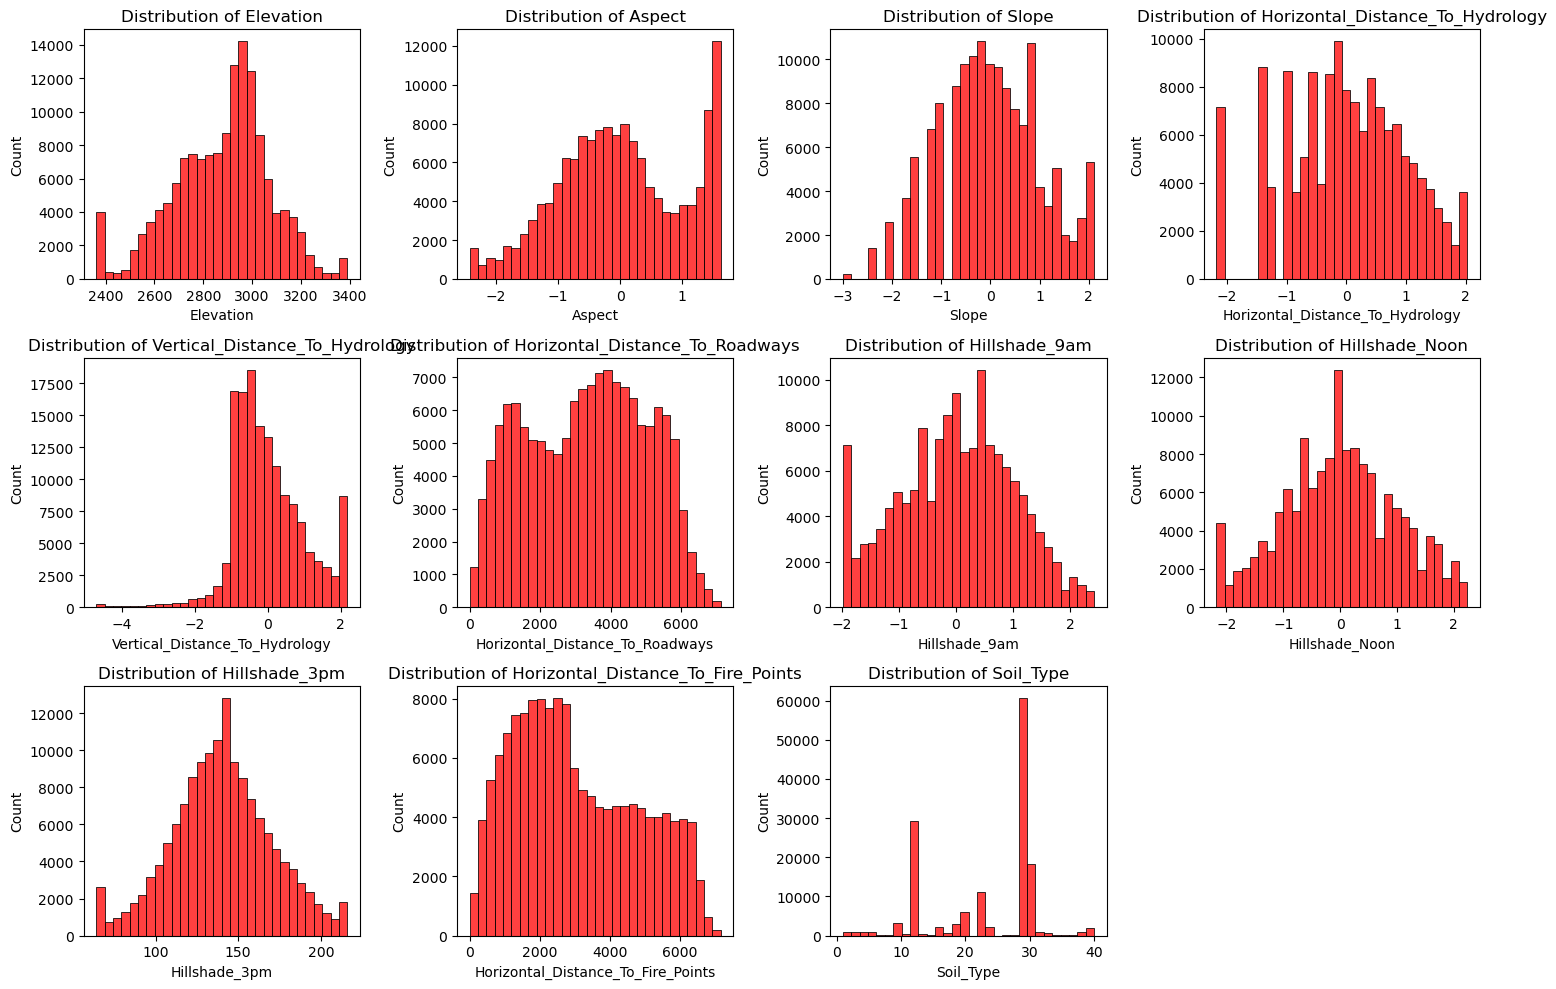

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns (excluding target)
num_cols = data.select_dtypes(include=['int64','float64']).columns

# Plot histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)  # Adjust grid size as needed
    sns.histplot(data[col], bins=30, color="red", edgecolor="black")
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [106]:
data["Cover_Type"].value_counts()

Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64

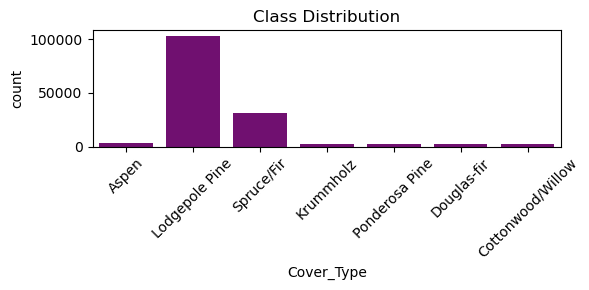

In [107]:
plt.figure(figsize=(6,3))
sns.countplot(x='Cover_Type', data=data, color="purple")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# “Cover_Type shows class imbalance with some classes dominating.”

<Figure size 800x800 with 0 Axes>

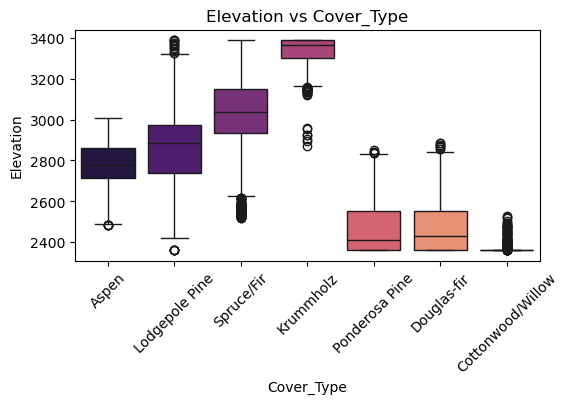

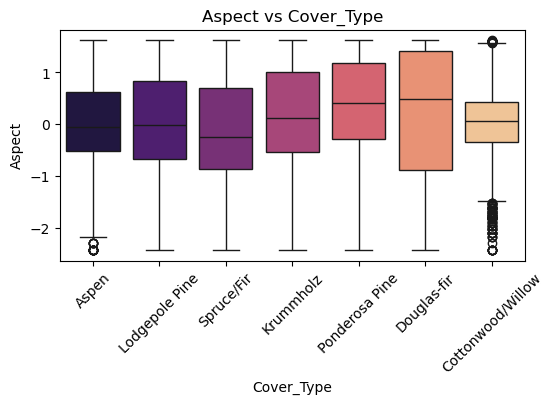

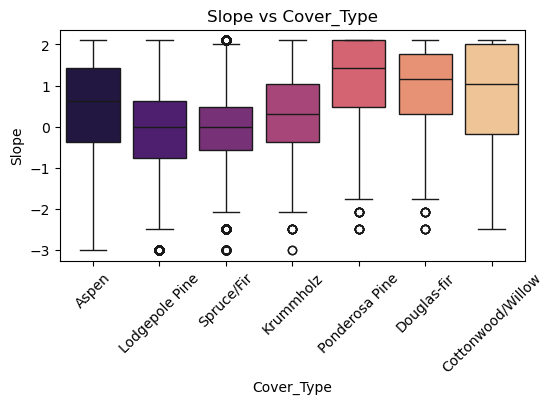

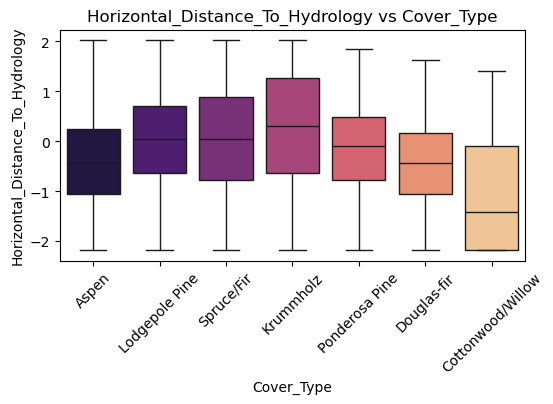

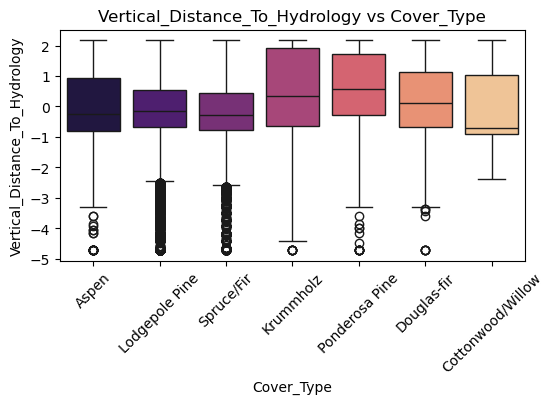

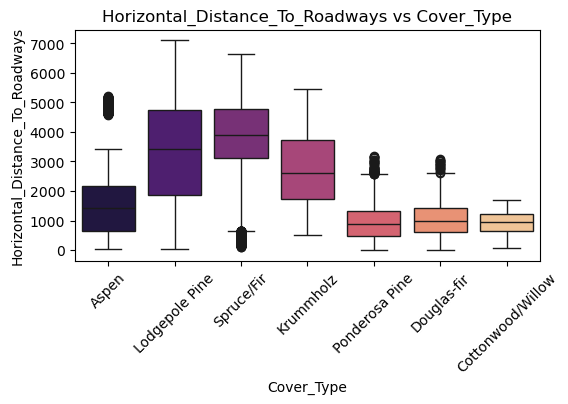

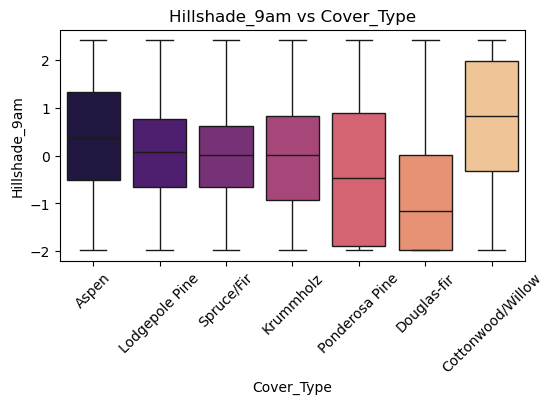

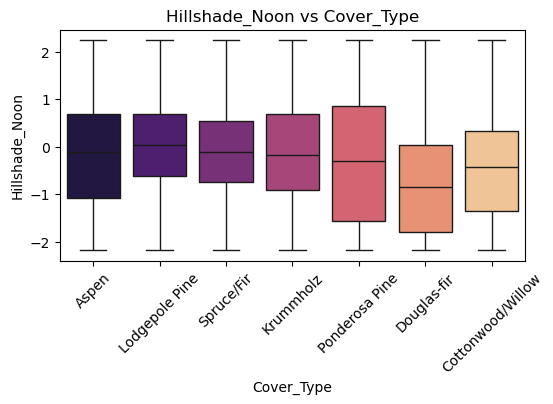

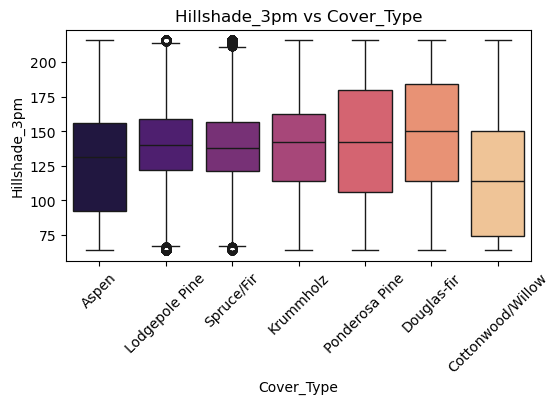

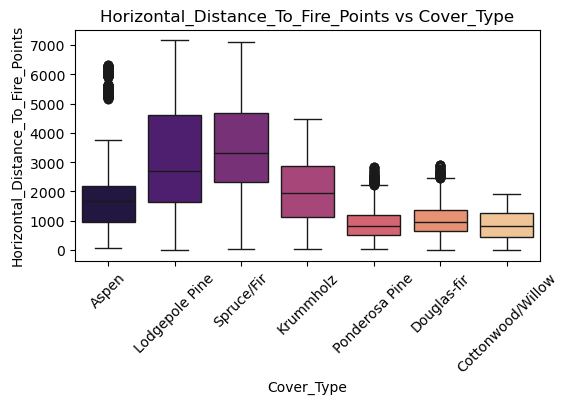

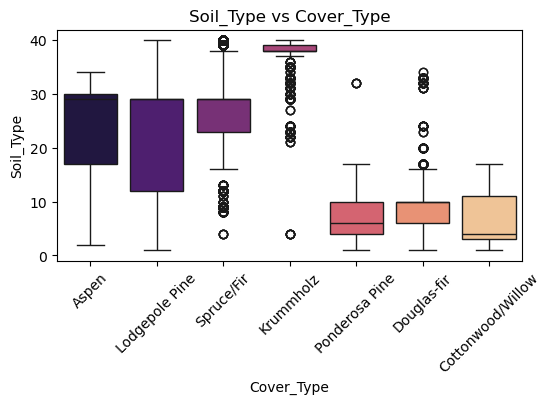

In [108]:
plt.figure(figsize=(8, 8))

for col in num_cols:
    plt.figure(figsize=(6,3))   # new figure for each column
    sns.boxplot(
    x='Cover_Type',
    y=col,
    hue='Cover_Type',
    data=data,
    palette='magma'
)
    
    plt.title(f"{col} vs Cover_Type")
    plt.xticks(rotation=45)

plt.show()

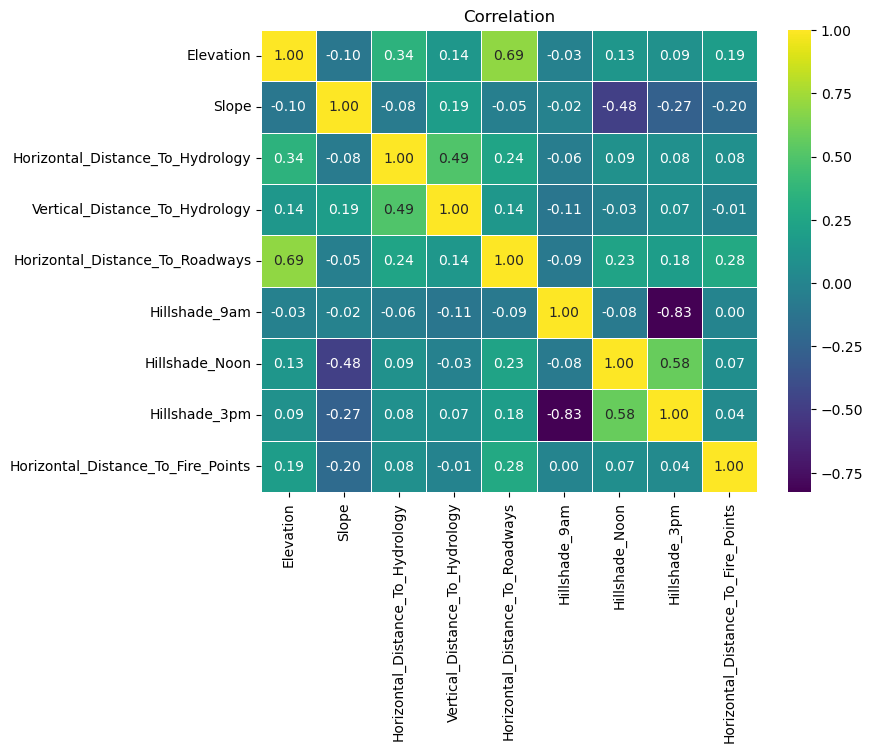

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_cols = [
    'Elevation',
    'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am',
    'Hillshade_Noon',
    'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

plt.figure(figsize=(8, 6))

corr_matrix = data[heatmap_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5
)

plt.title("Correlation")
plt.show()

# Based on the correlation matrix, here is an analysis of the relationships between the features themselves, which is useful for identifying multicollinearity:

# Hillshade_9am and Hillshade_3pm (-0.83): This is the strongest correlation in the dataset. These two variables are highly redundant (as one increases, the other decreases significantly), meaning you might only need one of them for your model.

# Elevation and Horizontal_Distance_To_Roadways (0.69): There is a strong positive relationship here, suggesting that higher elevation areas in this dataset tend to be further away from roads.

# Hillshade_Noon and Hillshade_3pm (0.58): A moderate positive correlation exists between midday and afternoon sun exposure, which is expected as the sun moves across the sky.

# Horizontal and Vertical Distance to Hydrology (0.49): These two show a moderate correlation, indicating that as the horizontal distance to water increases, the vertical elevation change relative to water often increases as well.

# Hillshade_Noon and Slope (-0.48): There is a moderate negative correlation, suggesting that steeper slopes might receive less direct sunlight at noon depending on their orientation.

# Encoding and feature engineering

In [110]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [111]:
# Convert degrees to radians first
data['Aspect_rad'] = np.deg2rad(data['Aspect'])

# Create cyclic features
data['Aspect_sin'] = np.sin(data['Aspect_rad'])
# Drop original columns
data.drop(['Aspect', 'Aspect_rad'], axis=1, inplace=True)

In [112]:
data = pd.get_dummies(data, columns=['Soil_Type'], drop_first=True)

In [113]:
le = LabelEncoder()
data['Cover_Type'] = le.fit_transform(data['Cover_Type'])

# “Aspect was transformed using sine to handle its cyclic nature, Soil_Type and Wilderness_Area were one-hot encoded as categorical variables, and the target Cover_Type was label encoded for classification.”

In [114]:
data.columns

Index(['Elevation', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Aspect_sin',
       'Soil_Type_2.0', 'Soil_Type_3.0', 'Soil_Type_4.0', 'Soil_Type_5.0',
       'Soil_Type_6.0', 'Soil_Type_7.0', 'Soil_Type_8.0', 'Soil_Type_9.0',
       'Soil_Type_10.0', 'Soil_Type_11.0', 'Soil_Type_12.0', 'Soil_Type_13.0',
       'Soil_Type_14.0', 'Soil_Type_16.0', 'Soil_Type_17.0', 'Soil_Type_18.0',
       'Soil_Type_19.0', 'Soil_Type_20.0', 'Soil_Type_21.0', 'Soil_Type_22.0',
       'Soil_Type_23.0', 'Soil_Type_24.0', 'Soil_Type_25.0', 'Soil_Type_26.0',
       'Soil_Type_27.0', 'Soil_Type_28.0', 'Soil_Type_29.0', 'Soil_Type_30.0',
       'Soil_Type_31.0', 'Soil_Type_32.0', 'Soil_Type_33.0', 'Soil_Type_34.0',
       'Soil_Type_35.0', 'Soil_Type_36.0', 'Soil_Type_37.0', 'Soil_Type_38.0',
       'Soil_Type_39.0',

In [115]:
data.head(3)

,Elevation,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,...,Soil_Type_31.0,Soil_Type_32.0,Soil_Type_33.0,Soil_Type_34.0,Soil_Type_35.0,Soil_Type_36.0,Soil_Type_37.0,Soil_Type_38.0,Soil_Type_39.0,Soil_Type_40.0
0,2596.0,-1.756890,0.258124,-0.915049,510.0,0.014542,0.390638,148.0,6279.0,0,...,False,False,False,False,False,False,False,False,False,False
1,2590.0,-2.084479,0.024593,-1.217221,390.0,-0.042148,0.616244,151.0,6225.0,0,...,False,False,False,False,False,False,False,False,False,False
2,2804.0,-0.364570,0.305943,0.930837,3180.0,0.832835,0.849998,135.0,6121.0,4,...,False,False,False,False,False,False,False,False,False,False


# Featur engineering

In [116]:
# 1. Total Hydrology Distance from water sources (very important for vegetation).
data['Hydrology_Distance'] = (
    data['Horizontal_Distance_To_Hydrology'] +
    abs(data['Vertical_Distance_To_Hydrology'])
)

# 2. Hydrology Distance Ratio - Represents terrain steepness near water.
data['Hydrology_Ratio'] = (
    data['Vertical_Distance_To_Hydrology'] /
    (data['Horizontal_Distance_To_Hydrology'] + 1)
)

# 3. Hillshade Mean - Represents overall sunlight exposure
data['Hillshade_Mean'] = (
    data['Hillshade_9am'] +
    data['Hillshade_Noon'] +
    data['Hillshade_3pm']
) / 3

# 4. Terrain Interaction Feature - Elevation + slope strongly influence tree growth.
data['Elevation_Slope'] = data['Elevation'] * data['Slope']

# They capture the most important forest factors:

Distance from water 🌊

Terrain steepness ⛰️

Sunlight exposure ☀️

Elevation impact 🌲

These give maximum improvement with minimum extra features.
“Four key engineered features were created: hydrology distance, hydrology ratio, hillshade mean, and elevation-slope interaction to capture terrain, sunlight, and environmental influences on forest cover.”

In [117]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(data['Cover_Type'])

In [118]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

# import joblib

le = joblib.load("label_encoder.pkl")
predicted_labels = le.inverse_transform(predictions)

# “Encoders are saved using joblib to preserve the learned category mappings. During inference, the same encoder is loaded and used only for transformation to ensure consistency between training and prediction.”

# Feature importances using Random Forest(Classification)

In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = data.drop('Cover_Type', axis=1)
y = data['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for classification
)
# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Create a DataFrame
feature_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
feature_importance_df


,Feature,Importance
0,Elevation,0.245645
4,Horizontal_Distance_To_Roadways,0.119998
8,Horizontal_Distance_To_Fire_Points,0.107777
48,Hydrology_Distance,0.043791
49,Hydrology_Ratio,0.042592
2,Horizontal_Distance_To_Hydrology,0.041752
3,Vertical_Distance_To_Hydrology,0.038244
9,Aspect_sin,0.037288
51,Elevation_Slope,0.037004
50,Hillshade_Mean,0.034557


# Bar Graph for Feature Importance

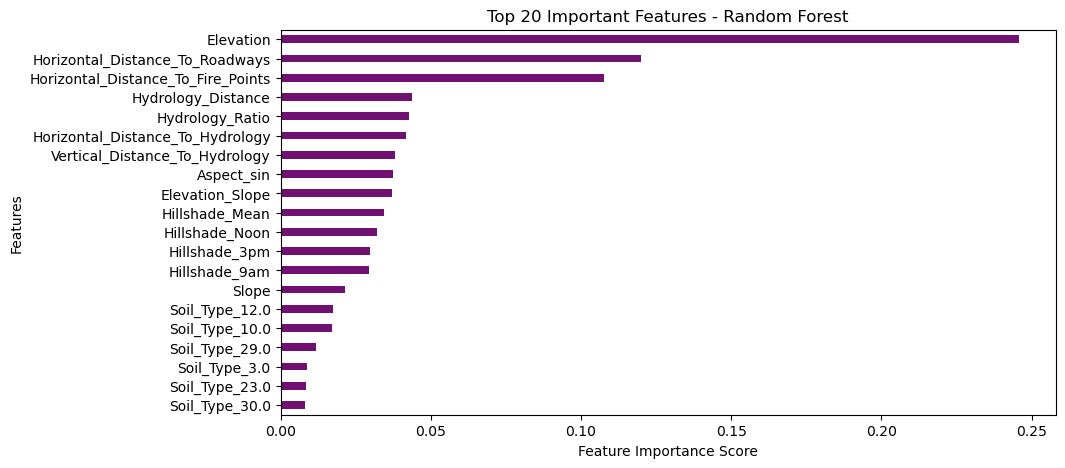

In [120]:
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance_df['Importance'][:20], y=feature_importance_df['Feature'][:20], color='purple', width=0.4)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Important Features - Random Forest")
plt.show()


In [121]:
len(data.columns)

53

In [122]:
# columns to consider

feature_importance_df['Feature'][:20].tolist()

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Hydrology_Distance',
 'Hydrology_Ratio',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Aspect_sin',
 'Elevation_Slope',
 'Hillshade_Mean',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Hillshade_9am',
 'Slope',
 'Soil_Type_12.0',
 'Soil_Type_10.0',
 'Soil_Type_29.0',
 'Soil_Type_3.0',
 'Soil_Type_23.0',
 'Soil_Type_30.0']

In [123]:
top_20 = ['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Hydrology_Distance',
 'Hydrology_Ratio',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Aspect_sin',
 'Elevation_Slope',
 'Hillshade_Mean',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Hillshade_9am',
 'Slope',
 'Soil_Type_12.0',
 'Soil_Type_10.0',
 'Soil_Type_29.0',
 'Soil_Type_3.0',
 'Soil_Type_23.0',
 'Soil_Type_30.0','Cover_Type']


filtered1 = data[top_20] # original data

filtered1.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Hydrology_Distance,Hydrology_Ratio,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Aspect_sin,Elevation_Slope,Hillshade_Mean,...,Hillshade_3pm,Hillshade_9am,Slope,Soil_Type_12.0,Soil_Type_10.0,Soil_Type_29.0,Soil_Type_3.0,Soil_Type_23.0,Soil_Type_30.0,Cover_Type
0,2596.0,510.0,6279.0,1.173173,-0.727312,0.258124,-0.915049,-0.013352,-4560.885708,49.468393,...,148.0,0.014542,-1.756890,False,False,True,False,False,False,0
1,2590.0,390.0,6225.0,1.241814,-1.188005,0.024593,-1.217221,-0.012005,-5398.801061,50.524699,...,151.0,-0.042148,-2.084479,False,False,True,False,False,False,0
2,2804.0,3180.0,6121.0,1.236781,0.712770,0.305943,0.930837,0.004059,-1022.254664,45.560944,...,135.0,0.832835,-0.364570,True,False,False,False,False,False,4
3,2785.0,3090.0,6211.0,2.361370,1.849682,0.179560,2.181810,0.006401,2880.056772,41.322305,...,122.0,1.116918,1.034132,False,False,False,False,False,True,4
4,2595.0,391.0,6172.0,0.642165,-1.407147,-0.317796,-0.959961,-0.015077,-5409.223457,50.165999,...,150.0,-0.042148,-2.084479,False,False,True,False,False,False,0


In [124]:
filtered1.to_csv("classification.csv", index=False)